In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from scipy import linalg as la
from matplotlib import pyplot as plt
import matplotlib

from tai_localiser.perulizer import proximity_lattice, proximity_bonds

from koala.lattice import Lattice
from koala import pointsets
from koala import plotting as pl

matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
        # reduce border width of plots
        "axes.linewidth": 0.5,
        "lines.linewidth": 0.5,
    }
)

import cmasher

aps_figwidth = 6.6
aps_halfwidth = 3.375

In [ ]:
def iterative_move_point(points_in, sigma, n_iterations, kappa, **kwargs):

    sigma_step = sigma / np.sqrt(n_iterations)
    kappa_step = kappa / n_iterations

    points = points_in.copy()
    for i in range(n_iterations):
        points = pointsets.move_all_points(points, sigma_step, kappa_step, **kwargs)

    return points

In [ ]:
# lets add a check of the graphs that we want to generate
from tqdm import tqdm


system_size = 20
beta = 1
sigma_bounds = (0.0, 1 / system_size)
kappa_shift = 0.15

repititions = 100
n_it = 3

n_points = 5
sigmas = np.linspace(sigma_bounds[0], sigma_bounds[1] * 2, n_points)


initial_points = pointsets.grid(system_size, system_size)
points_kappa = []
points_no_kappa = []
# generate the pointsets
for s in tqdm(sigmas):
    p_k = []
    p_nk = []
    for x in range(repititions):

        p_k.append(
            iterative_move_point(initial_points, s, n_it, kappa_shift, resolution=20)
        )
        p_nk.append(iterative_move_point(initial_points, s, n_it, 0, resolution=20))

    points_kappa.append(p_k)
    points_no_kappa.append(p_nk)

points_kappa = np.array(points_kappa)
points_no_kappa = np.array(points_no_kappa)

100%|██████████| 5/5 [25:37<00:00, 307.54s/it]


In [23]:
with open("results/structures/points_kappa.npy", "wb") as f:
    np.save(f, points_kappa)
with open("results/structures/points_no_kappa.npy", "wb") as f:
    np.save(f, points_no_kappa)

In [7]:
initial_points = pointsets.grid(30, 30)

s = 0.1

p = pointsets.move_all_points(initial_points, s, 0.5, 1, resolution=30)
# p = pointsets.move_all_points(initial_points, s, 0., 1, resolution=30)

In [8]:
# p = pointsets.bluenoise(50, 50,50)
p = pointsets.move_all_points(initial_points, s, 0.0, 1, resolution=30)

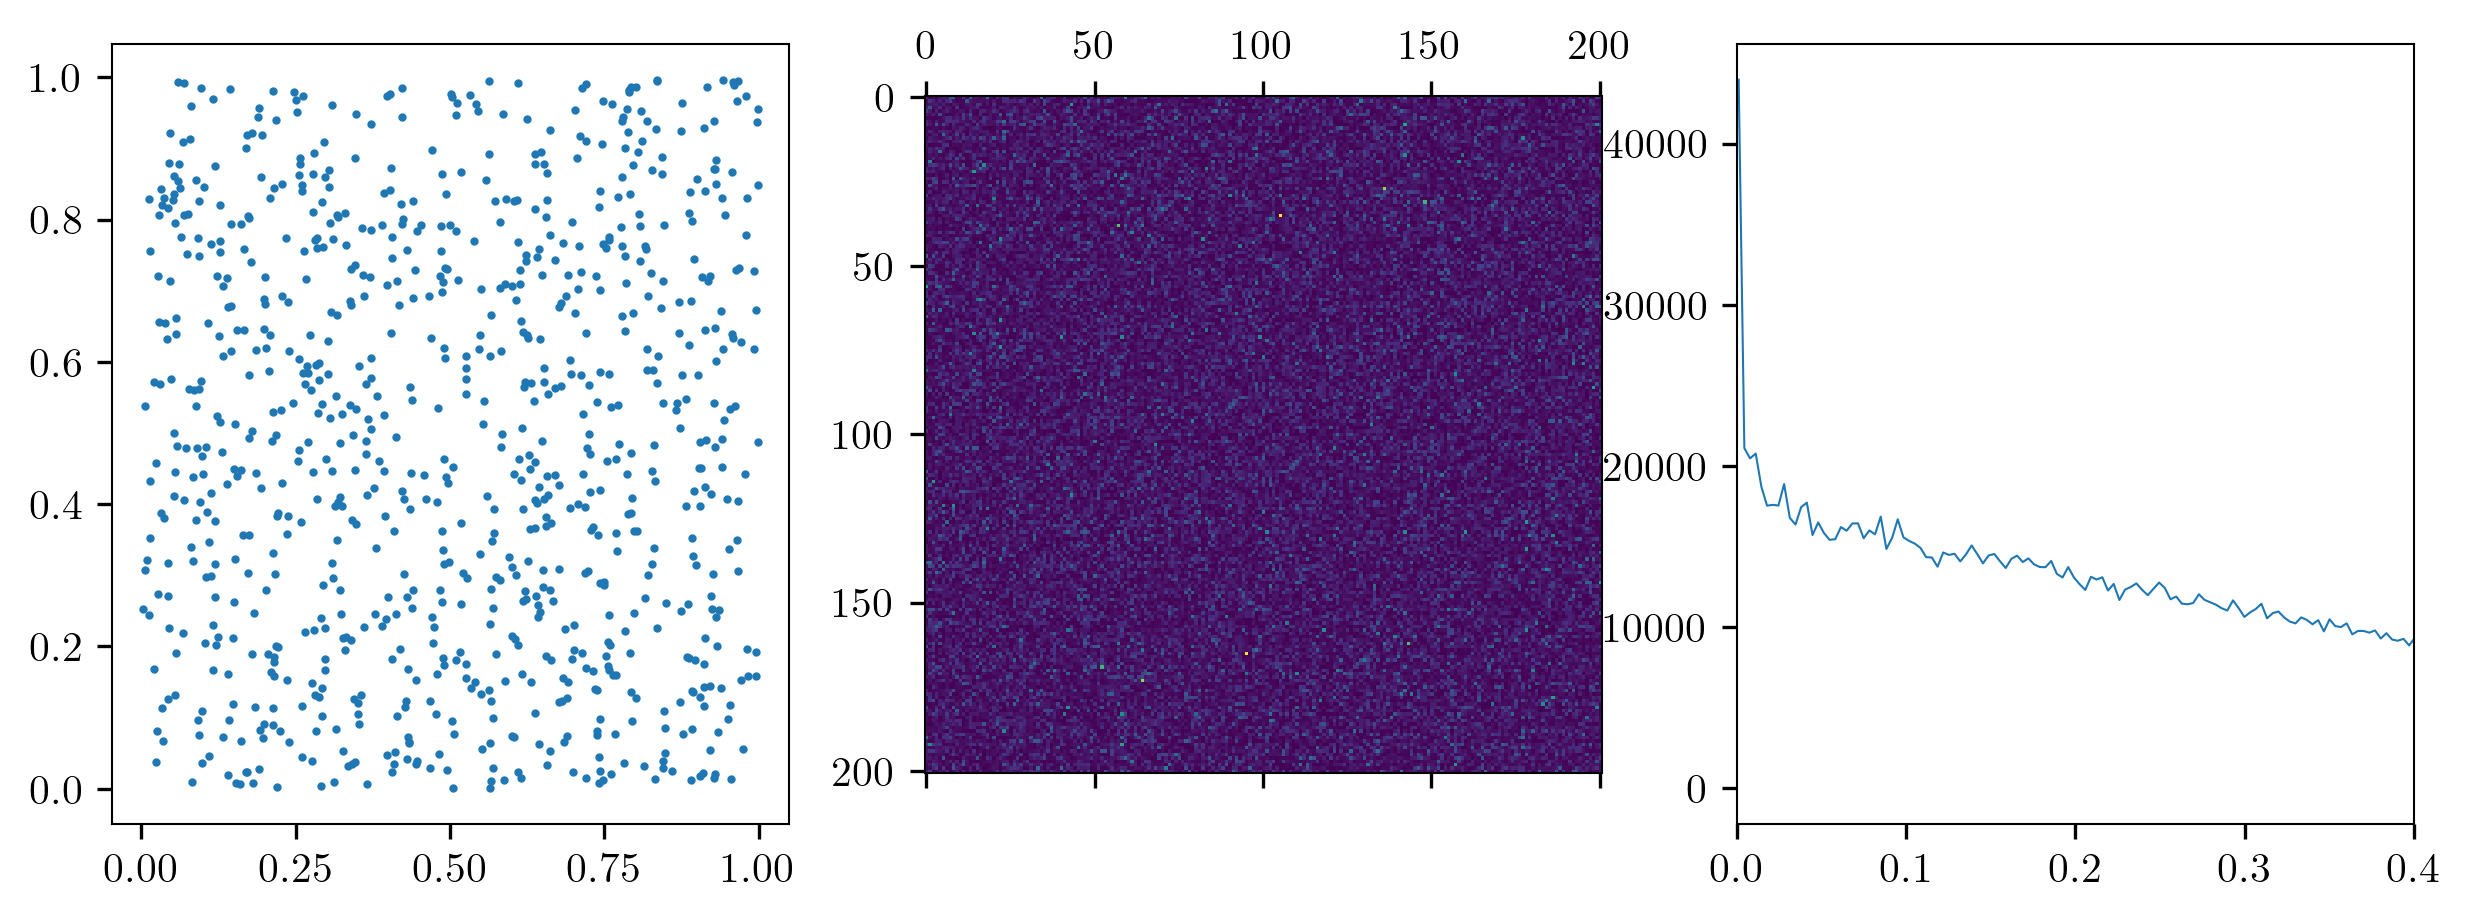

In [ ]:
def structure_factor(points, L):
    n_dims = points.shape[1]

    k = np.arange(-L, L + 1)
    k_grid = np.array(np.meshgrid(*[k] * n_dims)).T

    f_q = np.zeros(k_grid.shape[:-1], dtype=complex)
    for point in points:
        f_q += np.exp(-2j * np.pi * k_grid @ point)

    # remove 0,0 component
    f_q[L, L] = 1

    struct = (f_q * f_q.conj()).real / len(points)
    return struct


all_distances = la.norm((p[:, None] - p[None, :]).reshape(-1, 2), axis=1)
all_distances = all_distances[all_distances > 0]

x2 = structure_factor(p, 100)
fig, ax = plt.subplots(1, 3, figsize=(aps_figwidth * 1.5, aps_halfwidth), dpi=300)
ax[1].matshow(x2)
ax[0].scatter(*p.T, s=1)

c, x = np.histogram(all_distances, bins=400)

ax[2].plot(x[:-1], c / x[:-1])
ax[2].set_xlim(0, 0.4)
plt.show()

In [10]:
L = 40

u = lambda x: structure_factor(x, L)

# apply u to all the first two dimensions of points_kappa
struct_kappa = np.array([[u(points) for points in p_k] for p_k in points_kappa])
struct_no_kappa = np.array([[u(points) for points in p_nk] for p_nk in points_no_kappa])

In [11]:
struct_kappa = np.mean(struct_kappa, axis=1)
struct_no_kappa = np.mean(struct_no_kappa, axis=1)

(81, 81, 2)


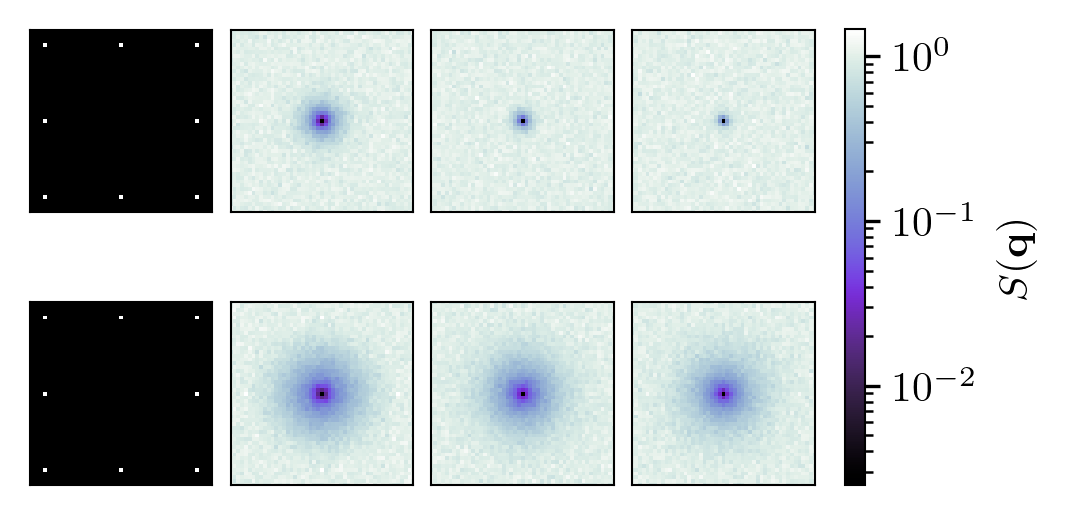

In [22]:
k = np.arange(-L, L + 1)
k_grid = np.array(np.meshgrid(*[k] * 2)).T

cmap = cmasher.amethyst

print(k_grid.shape)

fig, axes = plt.subplots(
    2,
    4,
    figsize=(aps_halfwidth, aps_halfwidth * 0.6),
    dpi=300,
)

# define global norm for all the plots
vmin = min(struct_kappa[1:].min(), struct_no_kappa[1:].min())
# vmin = max(vmin, 1e-1)
vmax = max(struct_kappa[1:].max(), struct_no_kappa[1:].max())
# vmax = max(vmin, 5)
norm = matplotlib.colors.LogNorm(vmin=vmin, vmax=vmax)
# norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)

for j, a in enumerate(axes[0]):
    # a.imshow(struct_no_kappa[j], origin="lower")
    # log colormap
    a.pcolormesh(*k_grid.T, struct_no_kappa[j], norm=norm, cmap=cmap)

for j, a in enumerate(axes[1]):
    # a.imshow(struct_kappa[j], origin="lower")
    # log colormap
    a.pcolormesh(*k_grid.T, struct_kappa[j], norm=norm, cmap=cmap)

r = 0.6
for a in axes.flatten():
    a.set_xticks([])
    a.set_yticks([])
    a.set_aspect("equal")
    a.set_xlim(-L * r, L * r)
    a.set_ylim(-L * r, L * r)

# add colorbar to the right of the last column
cbar_ax = fig.add_axes([0.93, 0.12, 0.02, 0.75])
cbar = fig.colorbar(
    matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=cbar_ax,
    label=r"$S(\mathbf{q})$",
)
fig.subplots_adjust(hspace=0.4, wspace=0.1)
plt.savefig("structure_factors.pdf", bbox_inches="tight")